📌 PARTE 1 — Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)

📌 PARTE 2 — Carregamento dos Dados

In [2]:
df = pd.read_csv("/content/dados_tratados.csv")

df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   Gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   Tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


In [4]:
df.describe()

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,2.158675,64.761692,2279.734304
std,24.559481,1.003088,30.090047,2266.794470
min,0.000000,0.610000,18.250000,0.000000
25%,9.000000,1.180000,35.500000,398.550000
50%,29.000000,2.340000,70.350000,1394.550000
75%,55.000000,2.990000,89.850000,3786.600000
max,72.000000,3.960000,118.750000,8684.800000


📌 PARTE 3 — LIMPEZA E CORREÇÕES IMPORTANTES

🔥 1) Remover ID (se existir)

In [5]:
if "customerID" in df.columns:
    df = df.drop("customerID", axis=1)

🔥 2) Converter colunas numéricas que vieram como string

In [6]:
for col in df.columns:
    if df[col].dtype == "object":
        try:
            df[col] = pd.to_numeric(df[col])
        except:
            pass

🔥 3) Aplicar OneHotEncoding automaticamente nas categóricas

In [7]:
df = pd.get_dummies(df, drop_first=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Columns: 7067 entries, Tenure to PaymentMethod_Mailed check
dtypes: bool(7063), float64(3), int64(1)
memory usage: 47.7 MB


📌 PARTE 4 — Definir Variável Alvo

In [9]:
for col in df.columns:
    if "churn" in col.lower():
        print(col)

Churn_Yes


In [10]:
target = "Churn_Yes"

X = df.drop(target, axis=1)
y = df[target]

In [11]:
df

,Tenure,ChargesDaily,ChargesMonthly,ChargesTotal,CustomerID_0003-MKNFE,CustomerID_0004-TLHLJ,CustomerID_0011-IGKFF,CustomerID_0013-EXCHZ,CustomerID_0013-MHZWF,CustomerID_0013-SMEOE,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,9,2.19,65.60,593.30,False,False,False,False,False,False,...,False,True,True,False,True,False,True,False,False,True
1,9,2.00,59.90,542.40,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,4,2.46,73.90,280.85,False,True,False,False,False,False,...,True,False,False,False,False,False,True,False,True,False
3,13,3.27,98.00,1237.85,False,False,True,False,False,False,...,True,False,True,True,False,False,True,False,True,False
4,3,2.80,83.90,267.40,False,False,False,True,False,False,...,False,True,True,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,13,1.84,55.15,742.90,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,True
7039,22,2.84,85.10,1873.70,False,False,False,False,False,False,...,False,False,False,True,False,False,True,False,True,False
7040,2,1.68,50.30,92.75,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
7041,67,2.26,67.85,4627.65,False,False,False,False,False,False,...,True,True,False,True,False,True,False,False,False,True


📌 PARTE 5 — Escalonamento

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

📌 PARTE 6 — Divisão Treino/Teste

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

📌 PARTE 7 — Treinar Modelos

🔵 Regressão Logística

In [14]:
modelo_lr = LogisticRegression(max_iter=2000)
modelo_lr.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

🟢 Random Forest

In [15]:
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

🟣 Gradient Boosting

In [16]:
modelo_gb = GradientBoostingClassifier(random_state=42)
modelo_gb.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

📌 PARTE 8 — Função de Avaliação Completa

In [17]:
def avaliar_modelo(nome, modelo):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:,1]

    print(f"\n===== {nome} =====")
    print("Acurácia:", accuracy_score(y_test, y_pred))
    print("Precisão:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

    print("\nRelatório:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Matriz de Confusão - {nome}")
    plt.show()

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1])
    plt.title(f"Curva ROC - {nome}")
    plt.show()

📌 PARTE 9 — Avaliar os modelos (Regressão Logística - Random Forest - Gradient Boosting)


===== Regressão Logística =====
Acurácia: 0.7884524372929484
Precisão: 0.6087786259541985
Recall: 0.5686274509803921
F1-Score: 0.5880184331797235
ROC-AUC: 0.8309880184501167

Relatório:
              precision    recall  f1-score   support

       False       0.85      0.87      0.86      1552
        True       0.61      0.57      0.59       561

    accuracy                           0.79      2113
   macro avg       0.73      0.72      0.72      2113
weighted avg       0.78      0.79      0.79      2113



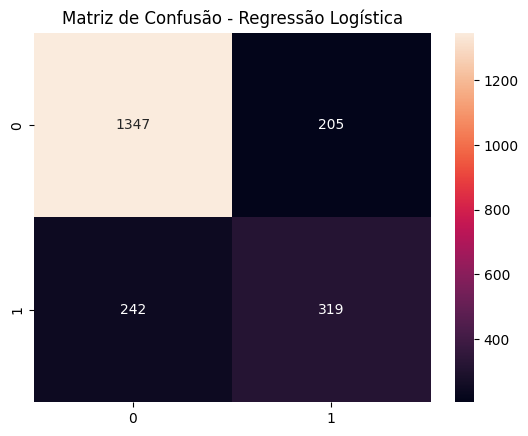

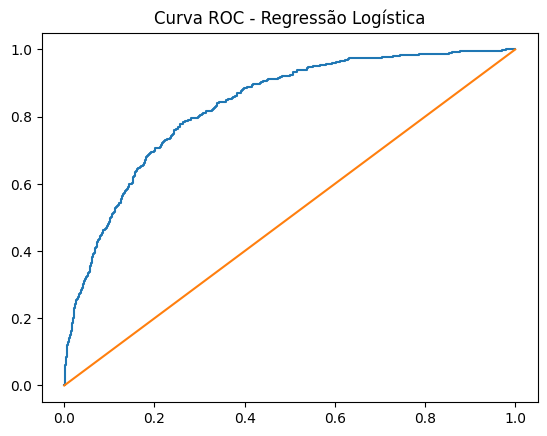


===== Random Forest =====
Acurácia: 0.7823000473260767
Precisão: 0.629156010230179
Recall: 0.4385026737967914
F1-Score: 0.5168067226890757
ROC-AUC: 0.8288264696694048

Relatório:
              precision    recall  f1-score   support

       False       0.82      0.91      0.86      1552
        True       0.63      0.44      0.52       561

    accuracy                           0.78      2113
   macro avg       0.72      0.67      0.69      2113
weighted avg       0.77      0.78      0.77      2113



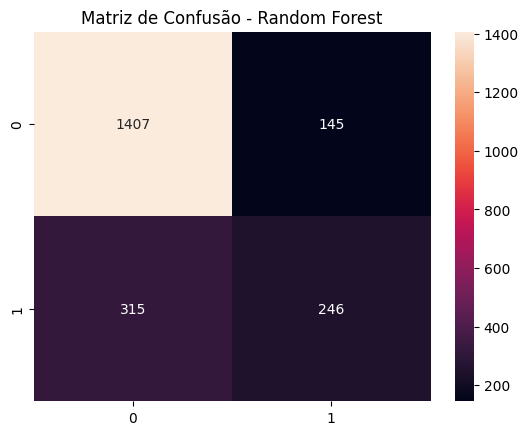

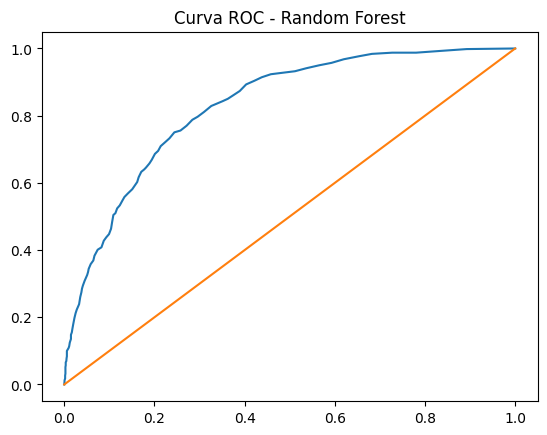


===== Gradient Boosting =====
Acurácia: 0.7879791765262659
Precisão: 0.6252771618625277
Recall: 0.5026737967914439
F1-Score: 0.5573122529644269
ROC-AUC: 0.8418784570998032

Relatório:
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1552
        True       0.63      0.50      0.56       561

    accuracy                           0.79      2113
   macro avg       0.73      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



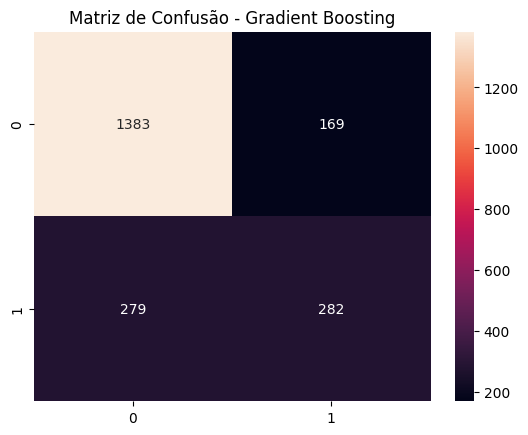

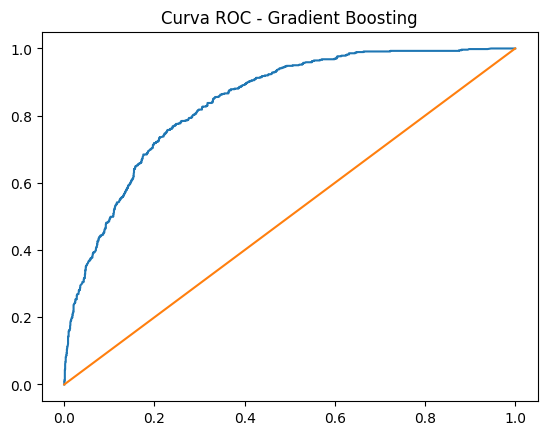

In [18]:
avaliar_modelo("Regressão Logística", modelo_lr)
avaliar_modelo("Random Forest", modelo_rf)
avaliar_modelo("Gradient Boosting", modelo_gb)

📌 PARTE 10 — Importância das Variáveis
- Random Forest

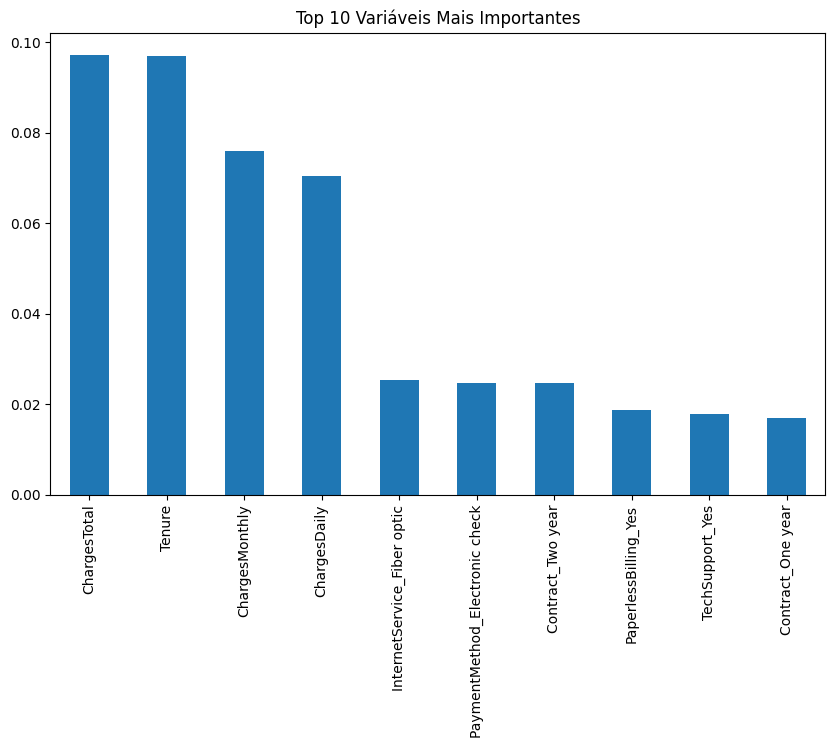

,0
ChargesTotal,0.097206
Tenure,0.096879
ChargesMonthly,0.075926
ChargesDaily,0.070355
InternetService_Fiber optic,0.025342
PaymentMethod_Electronic check,0.024695
Contract_Two year,0.024604
PaperlessBilling_Yes,0.018680
TechSupport_Yes,0.017822
Contract_One year,0.016908


In [19]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importancias.head(10).plot(kind="bar")
plt.title("Top 10 Variáveis Mais Importantes")
plt.show()

importancias.head(10)

🚀 GRÁFICO

📊 GRÁFICO 1 — Distribuição da Variável Alvo Churn

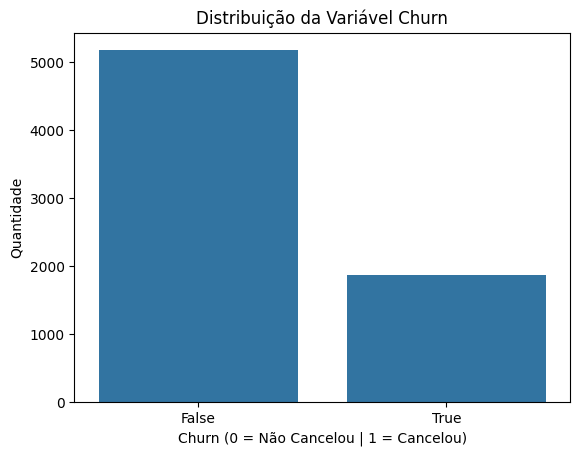

Proporção:
Churn_Yes
False    0.73463
True     0.26537
Name: proportion, dtype: float64


In [20]:
plt.figure()
sns.countplot(x=y)
plt.title("Distribuição da Variável Churn")
plt.xlabel("Churn (0 = Não Cancelou | 1 = Cancelou)")
plt.ylabel("Quantidade")
plt.show()

print("Proporção:")
print(y.value_counts(normalize=True))

🔥 GRÁFICO 2 — Matriz de Correlação

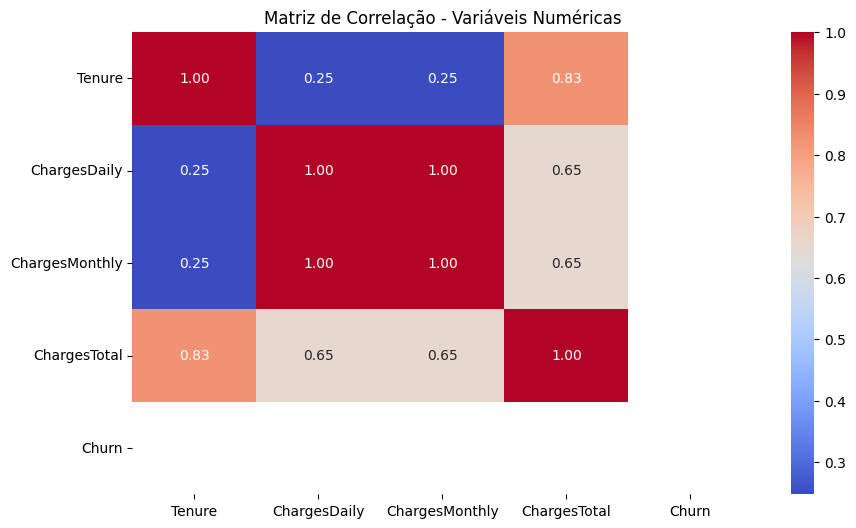

In [21]:
# Selecionar apenas variáveis numéricas
df_numeric = df.select_dtypes(include=["int64", "float64"])

# Converter Churn para numérico
df_numeric["Churn"] = df["Churn_Yes"].map({"Yes": 1, "No": 0})


# Calcular matriz de correlação
corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.show()

📈 GRÁFICO 3 — Curva ROC Comparativa (3 Modelos)

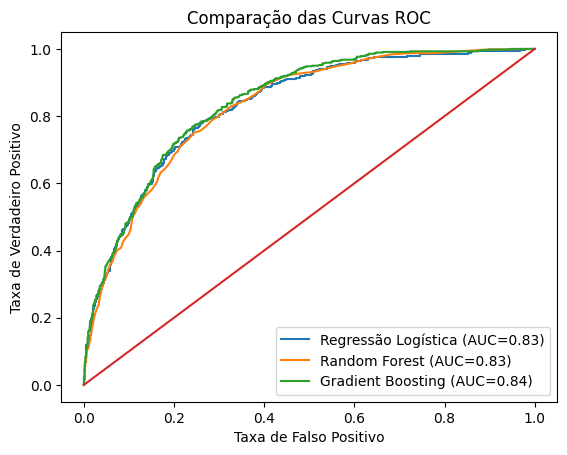

In [22]:
plt.figure()

for nome, modelo in {
    "Regressão Logística": modelo_lr,
    "Random Forest": modelo_rf,
    "Gradient Boosting": modelo_gb
}.items():

    y_prob = modelo.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{nome} (AUC={auc:.2f})")

plt.plot([0,1],[0,1])
plt.title("Comparação das Curvas ROC")
plt.xlabel("Taxa de Falso Positivo")
plt.ylabel("Taxa de Verdadeiro Positivo")
plt.legend()
plt.show()

📦 GRÁFICO 4 — Matriz de Confusão (Random Forest)

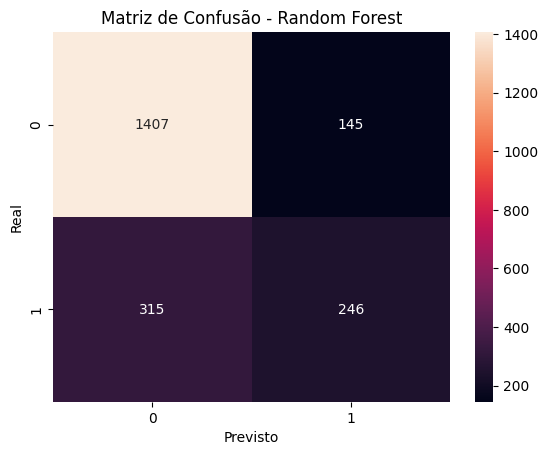

In [23]:
y_pred = modelo_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

🌳 GRÁFICO 5 — Importância das Variáveis

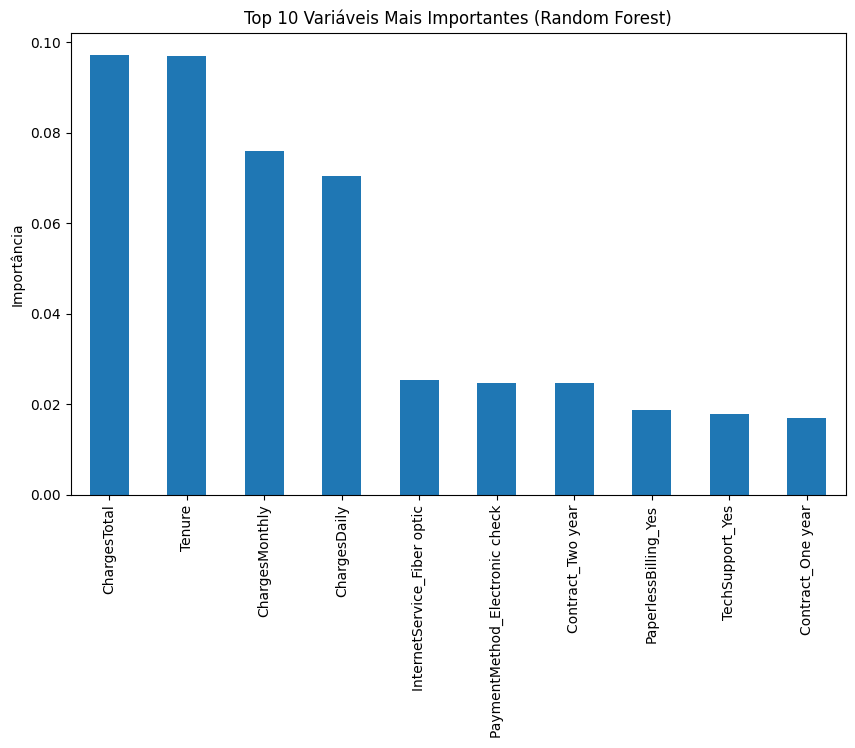

In [24]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importancias.head(10).plot(kind="bar")
plt.title("Top 10 Variáveis Mais Importantes (Random Forest)")
plt.ylabel("Importância")
plt.show()

📊 GRÁFICO 6 — Distribuição das Probabilidades de Cancelamento

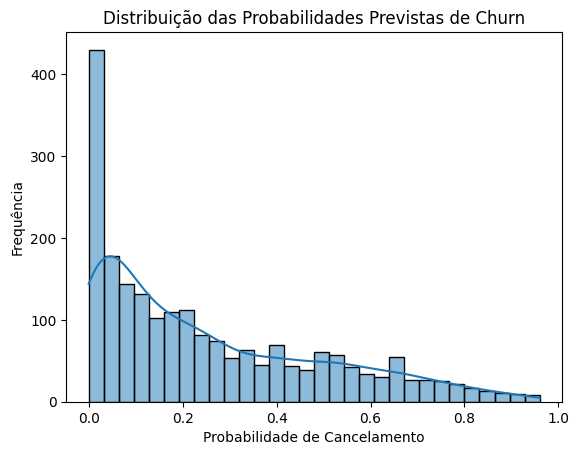

In [25]:
y_prob = modelo_rf.predict_proba(X_test)[:,1]

plt.figure()
sns.histplot(y_prob, bins=30, kde=True)
plt.title("Distribuição das Probabilidades Previstas de Churn")
plt.xlabel("Probabilidade de Cancelamento")
plt.ylabel("Frequência")
plt.show()

🏆 GRÁFICO — Comparação de Métricas

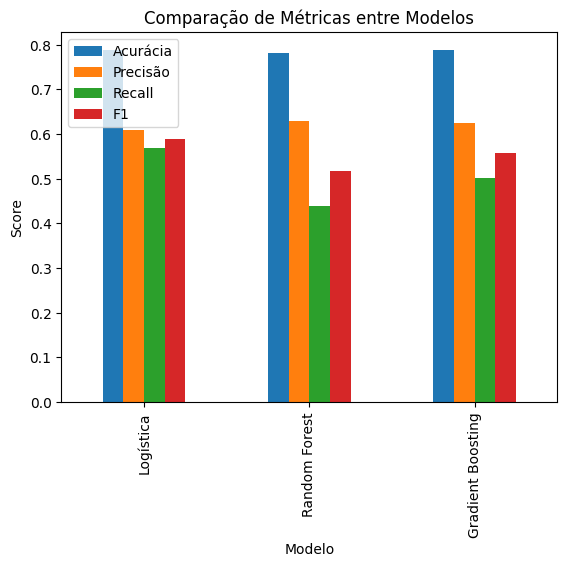

,Modelo,Acurácia,Precisão,Recall,F1
0,Logística,0.788452,0.608779,0.568627,0.588018
1,Random Forest,0.782300,0.629156,0.438503,0.516807
2,Gradient Boosting,0.787979,0.625277,0.502674,0.557312


In [26]:
resultados = []

for nome, modelo in {
    "Logística": modelo_lr,
    "Random Forest": modelo_rf,
    "Gradient Boosting": modelo_gb
}.items():

    y_pred = modelo.predict(X_test)
    resultados.append([
        nome,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

df_resultados = pd.DataFrame(resultados,
                             columns=["Modelo","Acurácia","Precisão","Recall","F1"])

df_resultados.set_index("Modelo").plot(kind="bar")
plt.title("Comparação de Métricas entre Modelos")
plt.ylabel("Score")
plt.show()

df_resultados

**🏆 Modelo Final Selecionado**

Embora o Gradient Boosting tenha apresentado o maior ROC-AUC (0.842), a **Regressão Logística** foi selecionada como modelo final por apresentar o maior Recall (0.569), métrica prioritária para o problema de churn.

Como o objetivo do projeto é identificar o maior número possível de clientes com risco real de cancelamento, o Recall torna-se a métrica mais relevante.

Além disso, a Regressão Logística apresentou o melhor F1-Score e maior interpretabilidade, facilitando a tomada de decisão estratégica.

Portanto, a Regressão Logística foi considerada o modelo mais adequado para implantação inicial.

**Métrica RECALL:**

Recall mede a capacidade do modelo de detectar corretamente os clientes que apresentam churn, minimizando Falsos Negativos — erro mais crítico para o negócio, pois representa perda direta de receita.

Dessa forma, optou-se por selecionar o modelo com maior Recall, garantindo maior eficiência na antecipação de evasões e permitindo ações estratégicas de retenção.